In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive

# 1. Mount Drive directly in this notebook
drive.mount('/content/drive')

# 2. Set working directory (Creates it if it doesn't exist)
working_dir = '/content/drive/MyDrive/RAI_Assignment_2'
os.makedirs(working_dir, exist_ok=True)
os.chdir(working_dir)
print(f"Working Directory set to: {os.getcwd()}")

# 3. Load the dataset
df = pd.read_csv('jigsaw-unintended-bias-train.csv')

# 4. Binarize the toxic column (>= 0.5 is toxic)
df['label'] = (df['toxic'] >= 0.5).astype(int)

# 5. Stratified Sampling
# Isolate the 120k rows we need in total, preserving the class ratio
df_subset, _ = train_test_split(
    df,
    train_size=120000,
    stratify=df['label'],
    random_state=42
)

# Split that 120k into 100k train and 20k eval
train_df, eval_df = train_test_split(
    df_subset,
    train_size=100000,
    stratify=df_subset['label'],
    random_state=42
)

print(f"Training set size: {len(train_df)} | Toxic ratio: {train_df['label'].mean():.4f}")
print(f"Evaluation set size: {len(eval_df)} | Toxic ratio: {eval_df['label'].mean():.4f}")

Mounted at /content/drive
Working Directory set to: /content/drive/MyDrive/RAI_Assignment_2
Training set size: 100000 | Toxic ratio: 0.0800
Evaluation set size: 20000 | Toxic ratio: 0.0799


In [2]:
import torch
from transformers import AutoTokenizer
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Convert to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df)
eval_dataset = Dataset.from_pandas(eval_df)

# Apply tokenization
train_dataset = train_dataset.map(lambda x: tokenizer(x["comment_text"], truncation=True, padding="max_length", max_length=128), batched=True)
eval_dataset = eval_dataset.map(lambda x: tokenizer(x["comment_text"], truncation=True, padding="max_length", max_length=128), batched=True)

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
eval_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

In [3]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

# Initialize the model
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Training arguments optimized for T4 GPU
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True,
    dataloader_num_workers=2,
    load_best_model_at_end=True
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset
)

# Start training
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.166756,0.133228
2,0.101262,0.136545
3,0.068152,0.176911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2346, training_loss=0.10598626669308922, metrics={'train_runtime': 849.2232, 'train_samples_per_second': 353.264, 'train_steps_per_second': 2.763, 'total_flos': 9935054899200000.0, 'train_loss': 0.10598626669308922, 'epoch': 3.0})

Accuracy: 0.9498
F1 (Macro): 0.8087
AUC-ROC: 0.9524


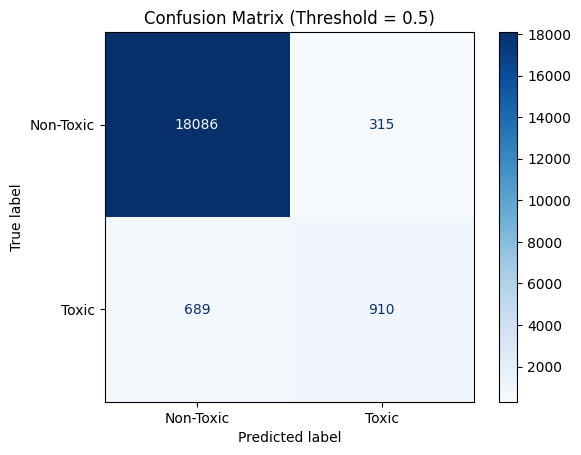

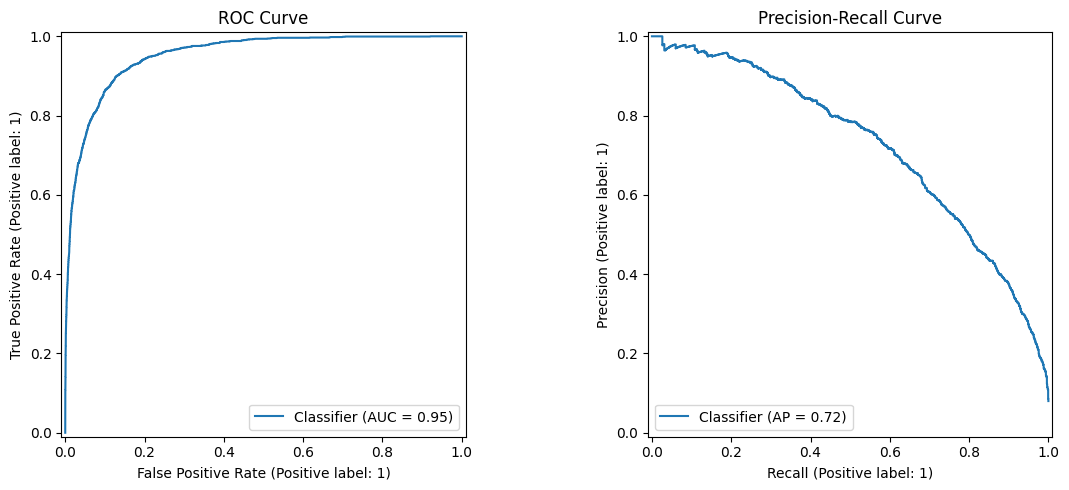

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from scipy.special import softmax

# Get predictions
predictions = trainer.predict(eval_dataset)
logits = predictions.predictions
probs = softmax(logits, axis=1)[:, 1] # Probability of class 1 (toxic)
true_labels = predictions.label_ids

# Default threshold 0.5
preds_05 = (probs >= 0.5).astype(int)

# 1. Core Metrics
print(f"Accuracy: {accuracy_score(true_labels, preds_05):.4f}")
print(f"F1 (Macro): {f1_score(true_labels, preds_05, average='macro'):.4f}")
print(f"AUC-ROC: {roc_auc_score(true_labels, probs):.4f}")

# 2. Confusion Matrix
cm = confusion_matrix(true_labels, preds_05)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Toxic", "Toxic"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

# 3. ROC and PR Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(true_labels, probs, ax=ax1)
ax1.set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(true_labels, probs, ax=ax2)
ax2.set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [5]:
# Evaluate different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print("F1 Scores (Macro) at various thresholds:")
for t in thresholds:
    temp_preds = (probs >= t).astype(int)
    f1 = f1_score(true_labels, temp_preds, average='macro')
    print(f"Threshold {t}: {f1:.4f}")

# Save the model and tokenizer to disk
trainer.save_model("./saved_model/baseline_distilbert")
tokenizer.save_pretrained("./saved_model/baseline_distilbert")
print("Model permanently saved to Google Drive!")

F1 Scores (Macro) at various thresholds:
Threshold 0.3: 0.8086
Threshold 0.4: 0.8143
Threshold 0.5: 0.8087
Threshold 0.6: 0.7961
Threshold 0.7: 0.7734


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model permanently saved to Google Drive!


### Threshold Selection & Platform Priorities

**Chosen Operating Threshold:** 0.4

**Mathematical Justification:** Based on the threshold sweep, an operating threshold of 0.4 maximizes the Macro F1 score (0.8142), providing the optimal mathematical balance between Precision and Recall across both classes on this specific validation set.

**Operational Implications:** Moving the threshold from the default 0.5 down to 0.4 implies a specific set of platform priorities:
1. **Prioritizing User Safety (Higher Recall):** By lowering the barrier for what constitutes a "toxic" prediction, the platform prioritizes catching a higher volume of genuinely toxic content. We are intentionally designing the system to be slightly more aggressive in its moderation.
2. **Accepting Higher Friction (False Positives):** The trade-off of a 0.4 threshold is a marginal increase in the False Positive Rate. The platform is signaling that it is willing to accept the operational cost of over-flagging a small percentage of innocent comments (which may require human review or user appeals) in exchange for minimizing the amount of abusive content that slips through the cracks to harm users.

In [12]:
import os
# Change this if you named your folder something else in Phase 0
working_dir = '/content/drive/MyDrive/RAI_Assignment_2'
os.chdir(working_dir)
print(f"Current Directory: {os.getcwd()}")

Current Directory: /content/drive/MyDrive/RAI_Assignment_2


In [14]:
%%bash
# Set identity locally to persist on your Drive
git config user.email "Fasihahmed229@gmail.com"
git config user.name "Fasih ur Rehman"

# Now commit the file
git add part1.ipynb
git commit -m "Complete Part 1: Baseline DistilBERT training and threshold analysis"

[master a64396d] Complete Part 1: Baseline DistilBERT training and threshold analysis
 1 file changed, 1 insertion(+)
 create mode 100644 part1.ipynb
